# Supporting Information I - HDI-like results for regional TSPO

AKA Pseudo-HDI. 

Importing fMRI data

In [ ]:
import numpy as np
import networkx as nx
import scipy.special as ss
from networkx import tree
import os
import glob
def adj_matrix_connected(corr_matrix,sparsity_value):
    """given the correlation matrix and the expected sparsity coefficient it can 
    happen that the corresponding thresholded matrix results in a disconnected graph
    here we force the graph to be fully connected by the computation of the minimum
    spanning tree and adding the required edges in order to have a unique connected component 
    """
    if sparsity_value == 1.0:
        adj_matrix=np.ones(corr_matrix.shape)
        np.fill_diagonal(adj_matrix,0)
        return adj_matrix
        
    
    corr_matrix =abs(corr_matrix)

    max_num_edges = ss.comb(corr_matrix.shape[0],2)
    num_edges = int(max_num_edges*sparsity_value)
    
    num_regions=corr_matrix.shape[0]
    #total number of regions in the graph
        
    totalgraph=nx.from_numpy_array(1-abs(corr_matrix))
    #extraction of a complete graph having has weight 1-abs(correlation)
    #we need to take 1-abs since the mst is taking the minimum weight graph and we want the most correlated edges to be there
    
    MST=nx.to_numpy_array(tree.minimum_spanning_tree(totalgraph).to_undirected())
    MST_adj_mat=MST
    MST_adj_mat[MST>0]==1
    MST_adj_mat=np.triu(MST_adj_mat) #put zeros in the inferior triangular matrix
    
    #put zeros in the diagonal of the corr matrix
    for i in range(num_regions):
        corr_matrix[i,i]=0
    
    values_corr=abs(np.triu(corr_matrix))
    
    cor_wo_MST=values_corr[np.triu(MST_adj_mat)==0]
    #we do not consider the correlation values which do not involve edges that are already in the MST
    
    values=list(cor_wo_MST.flatten())
    values.sort(reverse=True)
    
    #we select the maximum value of correlation to have the expected num of edges - num of edges in the mst (num regions-1)
    value_thresh=values[num_edges-(num_regions-1)-1] #-1 index start at 0
    
    adj_matrix=np.zeros(corr_matrix.shape) 
    
    #we put an edge if the value of correlation is higher than the found threshold or if the edges is required by the mst
    adj_matrix[values_corr>=value_thresh]=1
    adj_matrix[MST_adj_mat!=0]=1
    
    adj_matrix=np.triu(adj_matrix)+np.transpose(np.triu(adj_matrix)) #simmetry of the adj matrix
    
    return adj_matrix


In [ ]:

controls_aal = [
    "01FO", "02LE", "03GA", "04GM", "05IM", "07NA", "08CP", "09DM", "11GL", "12LJ",
    "13AE", "14PM", "15GT", "16DT", "17LY", "19DG", "20CP", "21LJ", "22DD", "23BA"
]

anoxic_aal = [ # Effective Anoxic patients
    "01JF", "02PD", "06BM", "07TA", "14RC"
]
traumatic_aal = [ # Effective Traumatic patients
    "03DB", "08PE", "11FC", "13TL", "16FF", "22BT", "23GC", "24ZX", "26AC"
]

matrices_path =  "/home/cabrerar/Documents/Paper_1/Data/Correlation_Matrices/AAL" 
control_path = os.path.join(matrices_path, "Controls")
anoxic_path = os.path.join(matrices_path, "Anoxic")
traumatic_path = os.path.join(matrices_path, "Traumatic")

# Final filter before importing - matching IDs from lists to files to exclude non-effective subjects

control_subjects = sorted(
    s for s in glob.glob(os.path.join(control_path, "*"))
    if os.path.basename(s).split(".")[0] in controls_aal
)

anoxic_subjects = sorted(
    s for s in glob.glob(os.path.join(anoxic_path, "*"))
    if os.path.basename(s).split(".")[0] in anoxic_aal
)

traumatic_subjects = sorted(
    s for s in glob.glob(os.path.join(traumatic_path, "*"))
    if os.path.basename(s).split(".")[0] in traumatic_aal
)

# Importing correlations - Keys are IDs, values are matrices

control_correlations = {}
for sub in control_subjects:
    control_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)


traumatic_correlations = {}
for sub in traumatic_subjects:
    traumatic_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)

anoxic_correlations = {}
for sub in anoxic_subjects:
    anoxic_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)

print(f"Controls: {len(control_correlations.keys())}, Anoxic: {len(anoxic_correlations.keys())}, Traumatic: {len(traumatic_correlations.keys())}")

# Constructing fMRI graphs

#costs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
costs = [0.1]

controls_fmri_graphs = {cost:{sub: None for sub in control_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in control_correlations.keys(): # Keys are IDs, values are nx.Graph objects
        controls_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(control_correlations[sub], cost))

anoxic_fmri_graphs = {cost:{sub: None for sub in anoxic_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in anoxic_correlations.keys():
        anoxic_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(anoxic_correlations[sub], cost))

traumatic_fmri_graphs = {cost:{sub: None for sub in traumatic_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in traumatic_correlations.keys():
        traumatic_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(traumatic_correlations[sub], cost))

# We can merge the coma dataset in one dictionary

coma_fmri_graphs = {cost: {} for cost in costs}

for cost in costs:
    coma_fmri_graphs[cost] = {**anoxic_fmri_graphs[cost], **traumatic_fmri_graphs[cost]}


Controls: 20, Anoxic: 5, Traumatic: 9


Regional TSPO

In [ ]:
import pandas as pd
tspo_path = "/Data/Regional_TSPO/AAL" # Idem, change the last path element to import another atlas
control_tspo_data = {}

control_tspo_files = glob.glob(os.path.join(tspo_path, "Controls", "*"))
for file in control_tspo_files:
    id = os.path.splitext(os.path.basename(file))[0] 
    control_tspo_data[id] = pd.read_csv(file)

anoxic_tspo_data = {}

anoxic_tspo_files = glob.glob(os.path.join(tspo_path, "Anoxic", "*"))
for file in anoxic_tspo_files:
    id = os.path.splitext(os.path.basename(file))[0] 
    if id in anoxic_aal:
        anoxic_tspo_data[id] = pd.read_csv(file)

traumatic_tspo_data = {}

traumatic_tspo_files = glob.glob(os.path.join(tspo_path, "Traumatic", "*"))
for file in traumatic_tspo_files:
    id = os.path.splitext(os.path.basename(file))[0]
    if id in traumatic_aal:
        traumatic_tspo_data[id] = pd.read_csv(file)

In [14]:
coma_tspo_data = {**anoxic_tspo_data, **traumatic_tspo_data}

Group-wise regional TSPO means

In [21]:
mode_cn = np.zeros((len(control_tspo_data.keys()), 89))
for i, px in enumerate(control_tspo_data.keys()):
    mode_cn[i] = control_tspo_data[px]['Mode']
m_mode_cn = np.mean(mode_cn, axis=0) # Mean regional TSPO for control subjects

m_mode_coma =  np.zeros((len(coma_tspo_data.keys()), 89))
for i, px in enumerate(coma_tspo_data.keys()):
    m_mode_coma[i] = coma_tspo_data[px]['Mode']
m_mode_coma = np.mean(m_mode_coma, axis=0) # Mean regiona TSPO for comatose patients


Coma subject IDs by outcome

In [6]:
favorable_group = ["06BM", "11FC", "12LY", "13TL", "14RC", "15GL", "18BE", "22BT", "23GC","24ZX", "25AY", "26AC"] # high CRS score
unfavorable_group = ["01JF", "02PD", "03DB", "04CD", "05ME","07TA","08PE","09CD","10CP","16FF","17MC","20MP","21GT"] # low CRS score or décès 


Let's compute HDI Degree with fMRI data

In [7]:
import numpy as np
import networkx as nx
from sklearn.linear_model import LinearRegression

def compute_baseline(graphs_dict, metric = "d"):
    """
    Compute baseline (mean degree or any metric per node) across all control graphs.
    graphs_dict: dict[sub_id -> nx.Graph]
    Returns: np.array of average degree/metric per node.
    """
    n_subjects = len(graphs_dict)
    example_sub = next(iter(graphs_dict.values()))
    n_regions = len(example_sub.nodes)
    metric_sum = np.zeros(n_regions)

    for sub, G in graphs_dict.items():
        if metric == "d":
            v = dict(nx.degree(G))
        elif metric == "cc":
            v = nx.clustering(G)
        elif metric == "cs":
            v = nx.closeness_centrality(G)
        else: 
            print("Error - metric not supported.")
            continue
        metric_sum += np.array([v[i] for i in range(n_regions)])

    baseline_metric = metric_sum / n_subjects
    return baseline_metric

# === HDI function, using precomputed graph dictionaries ===
def compute_HDI_ID(graphs_dict, baseline, metric="d"):
    """
    Compute HDI for a set of subject graphs, using a graph dictionary

    graphs_dict: dict[sub_id -> nx.Graph]
    baseline: np.array of control mean degree (or any node metric) per node

    Returns:
        list_subs: list of subject IDs
        res_HDI: np.array of HDI slopes
        dict_hdi: dict, subject id & HDI value
    """
    model = LinearRegression()
    list_subs = []
    res_HDI = np.zeros(len(graphs_dict))
    dict_hdi = {}

    for i, sub in enumerate(graphs_dict.keys()):
        try:
            list_subs.append(sub)
            G = graphs_dict[sub]
            if metric == "d":
                v = dict(nx.degree(G))
            elif metric == "cc":
                v = nx.clustering(G)
            elif metric == "cs":
                v = nx.closeness_centrality(G)
            else:
                print("Error - metric not supported.")
                continue
            vv = np.array(list(v.items()))  # same as original
            subj = vv[:, 1] - baseline
            x = baseline.reshape((-1, 1))
            y = subj
            model.fit(x, y)
            res_HDI[i] = model.coef_[0]
            dict_hdi[sub] = model.coef_[0]
        except Exception as e:
            print(f"Error processing {sub}: {e}")
            res_HDI[i] = np.nan

    #return list_subs, res_HDI
    return dict_hdi


In [8]:
# === HDI per subject, cost, and metric ===

metrics = ["d"] 

# === Containers ===
baseline_metrics_fmri = {m: {} for m in metrics}

HDI_results_fmri = {
    c: {m: {"Controls": {}, "Coma": {}} for m in metrics}
    for c in costs
}

# === Compute baseline metrics from controls ===
for cost in costs:
    for metric in metrics:
        baseline_metrics_fmri[metric][cost] = compute_baseline(
            controls_fmri_graphs[cost], metric
        )
        print(f"Computed baseline for cost {cost}, metric {metric}")

# === Define groups ===
groups = {
    "Controls": controls_fmri_graphs,
    "Anoxic": anoxic_fmri_graphs,
    "Traumatic": traumatic_fmri_graphs
}

# === Compute HDI ===
for cost in costs:
    for metric in metrics:
        baseline = baseline_metrics_fmri[metric][cost]

        for group_name, group_graphs in groups.items():

            dict_hdi = compute_HDI_ID(
                group_graphs[cost],
                baseline,
                metric
            )

            # Map groups → output structure
            target_group = "Controls" if group_name == "Controls" else "Coma"

            # Store results
            for sub, val in dict_hdi.items():
                HDI_results_fmri[cost][metric][target_group][sub] = val

            print(
                f"✓ {group_name} → {target_group}: "
                f"{metric} (cost={cost}) — {len(dict_hdi)} subjects"
            )

print("\nAll HDI computations complete.")


Computed baseline for cost 0.1, metric d
✓ Controls → Controls: d (cost=0.1) — 20 subjects
✓ Anoxic → Coma: d (cost=0.1) — 5 subjects
✓ Traumatic → Coma: d (cost=0.1) — 9 subjects

All HDI computations complete.


In [9]:
import pandas as pd
from scipy.stats import ttest_ind

# === Define group comparisons ===
group_comparisons = [
    ("Controls", "Coma")
    # ("Controls", "Anoxic"),
    # ("Controls", "Traumatic"),
    # ("Controls", "Favorable"),
    # ("Controls", "Unfavorable"),
    # ("Favorable", "Unfavorable"),
    # ("Anoxic", "Traumatic")
]

metrics = ["d"]

# === Collect results ===
rows = []

for cost in costs:
    for metric in metrics:

        # Base HDI data
        base_hdi = HDI_results_fmri[cost][metric]

        # === Rebuild groups (DO NOT mutate base_hdi) ===
        hdi_data = {}

        hdi_data["Controls"] = base_hdi.get("Controls", {})
        hdi_data["Coma"] = base_hdi.get("Coma", {})

        hdi_data["Anoxic"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in anoxic_aal
        }

        hdi_data["Traumatic"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in traumatic_aal
        }

        hdi_data["Favorable"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in favorable_group
        }

        hdi_data["Unfavorable"] = {
            k: v for k, v in hdi_data["Coma"].items() if k in unfavorable_group
        }

        # === Run t-tests ===
        for group_a, group_b in group_comparisons:

            vals_a = list(hdi_data.get(group_a, {}).values())
            vals_b = list(hdi_data.get(group_b, {}).values())

            if len(vals_a) > 1 and len(vals_b) > 1:
                t_stat, p_val = ttest_ind(vals_a, vals_b, nan_policy="omit")
            else:
                t_stat, p_val = np.nan, np.nan

            rows.append({
                "Cost": cost,
                "Metric": metric,
                "Group_A": group_a,
                "Group_B": group_b,
                "N_A": len(vals_a),
                "N_B": len(vals_b),
                "T_stat": t_stat,
                "P_value": p_val
            })

# === Final DataFrame ===
results_df = pd.DataFrame(rows)

results_df


,Cost,Metric,Group_A,Group_B,N_A,N_B,T_stat,P_value
0,0.1,d,Controls,Coma,20,14,3.933475,0.000422


HDI for regional aggragates of TSPO data, AKA _Pseudo-HDI_

In [ ]:
# === HDI function, using precomputed graph dictionaries ===
def compute_pseudo_HDI_ID(data_dict, baseline):
    """
    Compute pseudo-HDI for a set of subject data, using a  dictionary
    """
    model = LinearRegression()
    list_subs = []
    res_HDI = np.zeros(len(data_dict))

    for i, sub in enumerate(data_dict.keys()):
        try:
            list_subs.append(sub)
            # G = data_dict[sub]
            # if metric == "d":
            #     v = dict(nx.degree(G))
            # elif metric == "cc":
            #     v = nx.clustering(G)
            # elif metric == "cs":
            #     v = nx.closeness_centrality(G)
            # else:
            #     print("Error - metric not supported.")
            #     continue
            vv = data_dict[sub]
            #vv = np.array(list(v.items()))  # same as original
            #vv = v.to_numpy()
            #subj = vv[:, 1] - baseline
            subj = vv - baseline
            x = baseline.reshape((-1, 1))
            y = subj
            model.fit(x, y)
            res_HDI[i] = model.coef_[0]
        except Exception as e:
            print(f"Error processing {sub}: {e}")
            res_HDI[i] = np.nan

    return list_subs, res_HDI


In [16]:
regional_tspo_controls = {}
for sub in control_tspo_data.keys():
    regional_tspo_controls[sub] = control_tspo_data[sub]['Mode'].to_numpy()

In [18]:
regional_tspo_coma = {}
for sub in coma_tspo_data.keys():
    regional_tspo_coma[sub] = coma_tspo_data[sub]['Mode'].to_numpy()

In [19]:
def metrics_to_df_pseudo(metrics_dict, group_name, metric_name="TSPO"):
    """
    metrics_dict: {subject_id: scalar_value}
    """
    records = []
    for sub, value in metrics_dict.items():
        records.append({
            "subject": sub,
            "group": group_name,
            "metric": metric_name,   # <<< IMPORTANT
            "value": float(value)
        })
    return pd.DataFrame(records)


In [20]:

def run_t_tests(metrics_df, group_col="group", group_pairs=None):
    results = []
    for metric in metrics_df["metric"].unique():
        if group_pairs is None:
            # run all-vs-all comparisons if multiple groups exist
            unique_groups = metrics_df[group_col].unique()
            group_pairs = [(g1, g2) for i, g1 in enumerate(unique_groups)
                            for g2 in unique_groups[i+1:]]
        for g1, g2 in group_pairs:
            vals1 = metrics_df[(metrics_df[group_col] == g1) & 
                                
                                (metrics_df["metric"] == metric)]["value"]
            vals2 = metrics_df[(metrics_df[group_col] == g2) & 
                                
                                (metrics_df["metric"] == metric)]["value"]
            if len(vals1) > 0 and len(vals2) > 0:
                stat, pval = ttest_ind(vals1, vals2)
                # if pval == 1:
                #     print(len(vals1))
                #     print(len(vals2))
                results.append({
                    "metric": metric,
                    "group1": g1,
                    "group2": g2,
                    "t": stat,
                    "p": pval
                })
    return pd.DataFrame(results)


In [22]:
a, b = compute_pseudo_HDI_ID(regional_tspo_controls, m_mode_cn) # Controls TSPO "Pseudo" HDI 
c, d = compute_pseudo_HDI_ID(regional_tspo_coma, m_mode_cn) # Coma TSPO "Pseudo" HDI

controls_pseudo_hdi = {}

for i, sub in enumerate(a):
    controls_pseudo_hdi[sub] = b[i]

coma_pseudo_hdi = {}

for i, sub in enumerate(c):
    coma_pseudo_hdi[sub] = d[i]

In [31]:
def fmri_hdi_to_df(fmri_hdi, groups=None):
    """
    Converts fmri_hdi dict:
    {metric -> group -> subject -> value}
    into long-format DataFrame
    """
    records = []

    for metric, group_dict in fmri_hdi.items():
        for group, subj_dict in group_dict.items():
            if groups is not None and group not in groups:
                continue
            for subject, value in subj_dict.items():
                records.append({
                    "subject": subject,
                    "group": group,
                    "metric": metric,
                    "value": value
                })

    return pd.DataFrame(records)

metrics_df_fmri = fmri_hdi_to_df(
    HDI_results_fmri[0.1],
    groups=["Controls", "Coma"]
)
#metrics_df_fmri


In [ ]:
def run_tt(df, group_pairs):
    results = []
    for metric in df["metric"].unique():
        for g1, g2 in group_pairs:
            v1 = df[(df["group"]==g1) & (df["metric"]==metric)]["value"]
            v2 = df[(df["group"]==g2) & (df["metric"]==metric)]["value"]
            #stat, p = mannwhitneyu(v1, v2, alternative="two-sided")
            stat, p = ttest_ind(v1, v2)
            results.append({"metric": metric, "group1": g1, "group2": g2, "p": p})
    return pd.DataFrame(results)

results_df_fmri = run_tt(
    metrics_df_fmri,
    [("Controls", "Coma")]
)
#results_df_fmri


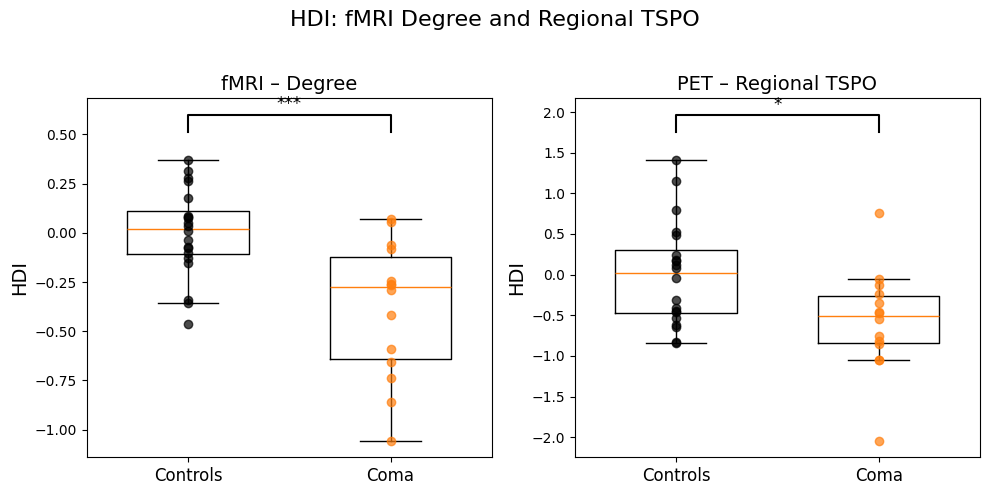

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
#from scipy.stats import mannwhitneyu

# =========================================================
# HELPER FUNCTIONS
# =========================================================
def metrics_to_df_pseudo(metrics_dict, group_name, metric_name=None):
    """
    Converts pseudo-HDI dictionaries to long-format DataFrame.
    """
    records = []
    for sub, metrics in metrics_dict.items():
        if isinstance(metrics, dict):
            # multiple metrics (fMRI)
            for mname, value in metrics.items():
                records.append({
                    "subject": sub,
                    "group": group_name,
                    "metric": mname,
                    "value": value
                })
        else:
            # single metric (TSPO)
            records.append({
                "subject": sub,
                "group": group_name,
                "metric": metric_name or "TSPO",
                "value": metrics
            })
    return pd.DataFrame(records)


def add_pval_bracket(ax, x1, x2, y, height, p_val):
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], color="black")
    if p_val < 0.001:
        sig = "***"
    elif p_val < 0.01:
        sig = "**"
    elif p_val < 0.05:
        sig = "*"
    else:
        sig = "#"
    ax.text((x1 + x2)/2, y + height + 0.01, sig, ha="center", va="bottom", fontsize=12)

def run_tt(df, group_pairs):
    results = []
    for metric in df["metric"].unique():
        for g1, g2 in group_pairs:
            v1 = df[(df["group"]==g1) & (df["metric"]==metric)]["value"]
            v2 = df[(df["group"]==g2) & (df["metric"]==metric)]["value"]
            #stat, p = mannwhitneyu(v1, v2, alternative="two-sided")
            stat, p = ttest_ind(v1, v2)
            results.append({"metric": metric, "group1": g1, "group2": g2, "p": p})
    return pd.DataFrame(results)

# =========================================================
df_controls = metrics_to_df_pseudo(controls_pseudo_hdi, "Controls")
df_coma     = metrics_to_df_pseudo(coma_pseudo_hdi, "Coma")
metrics_df_tspo = pd.concat([df_controls, df_coma], ignore_index=True)

results_df_tspo = run_tt(metrics_df_tspo, [("Controls", "Coma")])

# =========================================================
# PLOT ONE ROW: fMRI + TSPO
# =========================================================
groups = ["Controls", "Coma"]
group_colors = {"Controls":"black", "Coma":"tab:orange"}

plot_columns = [
    {"title":"fMRI – Degree",     "df":metrics_df_fmri, "metric":"d"},
    {"title":"PET – Regional TSPO","df":metrics_df_tspo, "metric":"TSPO"}  # <<< FIX
]

fig, axes = plt.subplots(1, len(plot_columns), figsize=(5*len(plot_columns),5), squeeze=False)
axes = axes[0]

for col, spec in enumerate(plot_columns):
    ax = axes[col]
    df = spec["df"]
    metric = spec["metric"]
    data = [df[(df["group"]==g) & (df["metric"]==metric)]["value"].values for g in groups]

    # Boxplot
    ax.boxplot(data, positions=range(len(groups)), widths=0.6, showfliers=False)

    # Scatter
    for x, (group, vals) in enumerate(zip(groups, data)):
        ax.scatter(np.full(len(vals), x), vals, color=group_colors[group], alpha=0.7, zorder=3)
    non_empty = [vals for vals in data if len(vals) > 0]

    if len(non_empty) == 0:
        ax.text(
            0.5, 0.5, "No data",
            transform=ax.transAxes,
            ha="center", va="center",
            fontsize=12
        )
        continue

    ymax = max(v.max() for v in non_empty)
    ymin = min(v.min() for v in non_empty)
    yrange = ymax - ymin if ymax != ymin else 1

    #yrange = ymax - ymin if ymax != ymin else 1
    base_height = ymax + 0.10*yrange
    step = 0.10*yrange

    # Fetch p-value
    results_df = results_df_fmri if "fMRI" in spec["title"] else results_df_tspo
    row = results_df[(results_df["metric"]==metric) & 
                     (results_df["group1"]==groups[0]) & 
                     (results_df["group2"]==groups[1])]
    if not row.empty:
        p_val = row["p"].values[0]
        if p_val < 0.1:
            add_pval_bracket(ax, 0, 1, base_height, step*0.6, p_val)

    # Axis formatting
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, fontsize=12)
    ax.set_title(spec["title"], fontsize=14)
    #ax.set_ylabel("HDI" if "fMRI" in spec["title"] else "Pseudo-HDI")
    ax.set_ylabel("HDI", fontsize=14)

fig.suptitle("HDI: fMRI Degree and Regional TSPO", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("/I/HDI Regional TSPO.png", dpi=200)
plt.show()
